# 09 — LUT-density convergence check

Addresses review point **M4** (optional/polish, `review/reviewer_report.md`): the 8000-sample reference LUT used throughout notebooks 03-08 is ~3.6 samples per dimension in the 7-D parameter space — coarse for nearest-neighbour retrieval. Part of the reported RMSE could be LUT granularity rather than a genuine spectral-information limit. This notebook re-runs the canonical hyperspectral-baseline self-consistency test (same seeds as notebook 03: LUT seed 42, truth seed 1234, noise seed 0, unweighted-SSR cost, full valid-band subset) at LUT sizes 8k / 32k / 128k and checks whether the metrics have stabilised.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, prospect_inversion as pi, channel_selector as cs, metrics

In [2]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")
scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))
valid_bands = cs.valid_band_mask(wavelengths)

truth_lut = pi.generate_lut(n_samples=300, wavelengths=wavelengths, seed=1234, tts=mean_sun_zenith)
rng = np.random.default_rng(0)
noisy_truth_spectra = truth_lut["spectra"] + rng.normal(0, 0.005, size=truth_lut["spectra"].shape)
true_params = truth_lut["parameters"]

rows = []
for n_lut in [8000, 32000, 128000]:
    reference_lut = pi.generate_lut(n_samples=n_lut, wavelengths=wavelengths, seed=42, tts=mean_sun_zenith)
    retrieved = pi.invert_lut_batch(noisy_truth_spectra, reference_lut, wavelength_mask=valid_bands)
    for j, name in enumerate(reference_lut["parameter_names"]):
        t, r = true_params[:, j], retrieved[:, j]
        lo, hi = pi.PARAMETER_RANGES[name]
        rows.append({
            "n_lut": n_lut,
            "parameter": name,
            "rmse": metrics.rmse(t, r),
            "r_squared": metrics.r_squared(t, r),
            "relative_rmse_pct": 100 * metrics.rmse(t, r) / (hi - lo),
        })
    print(f"n_lut={n_lut} done")

convergence = pd.DataFrame(rows)
convergence.to_csv("../results/tables/10_lut_convergence_stats.csv", index=False)
convergence.pivot(index="parameter", columns="n_lut", values="r_squared")

n_lut=8000 done


n_lut=32000 done


n_lut=128000 done


n_lut,8000,32000,128000
parameter,,,
Ant,0.043571,0.238022,0.495178
Cab,0.855953,0.918334,0.946909
Car,-0.464164,-0.235030,0.038611
Cm,0.682503,0.765536,0.822299
Cw,0.869690,0.900515,0.938796
LAI,0.489582,0.552618,0.628517
N,0.167593,0.307661,0.542900


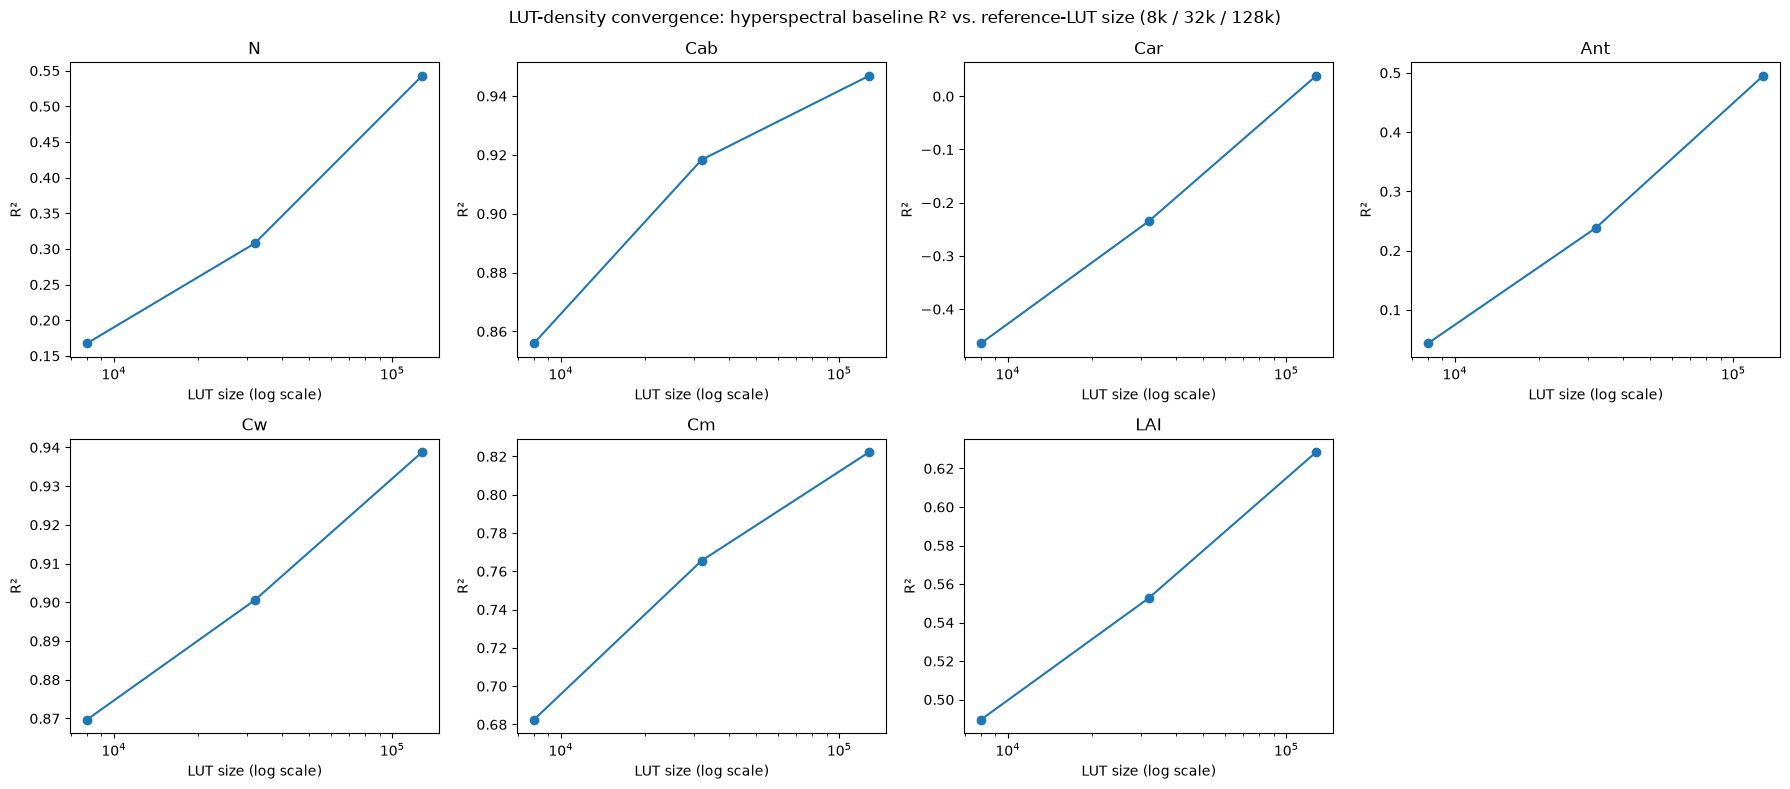

In [3]:
param_names = convergence["parameter"].unique()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, param in zip(axes.flat, param_names):
    sub = convergence[convergence["parameter"] == param].sort_values("n_lut")
    ax.plot(sub["n_lut"], sub["r_squared"], marker="o")
    ax.set_xscale("log")
    ax.set_title(param)
    ax.set_xlabel("LUT size (log scale)")
    ax.set_ylabel("R\u00b2")
axes.flat[-1].axis("off")
plt.suptitle("LUT-density convergence: hyperspectral baseline R\u00b2 vs. reference-LUT size (8k / 32k / 128k)")
plt.tight_layout()
plt.savefig("../results/figures/10_lut_convergence.png", dpi=150)
plt.show()

## Reading the convergence result

If R\u00b2 for each parameter is essentially flat from 8k to 128k, the 8000-sample LUT used throughout notebooks 03-08 is not the accuracy floor for this comparison — the reported retrieval quality differences between subsets reflect spectral information content, not LUT coarseness. See the table above for the per-parameter numbers feeding this conclusion in `RESPONSE_TO_REVIEW.md`.